# Dashboard - Desafio Lighthouse LH Nautical 

**Análise consolidada dos principais achados: clientes fiéis, sazonalidade de vendas, previsão de demanda e sistema de recomendação.** 

Dados: PostgreSQL local (`lh_nautical`) | Autor: Maurício Lobo

In [ ]:
import pandas as pd 
import psycopg2 
import matplotlib.pyplot as plt 

DB_NAME = "lh_nautical" 

def conectar(): 
  return psycopg2.connect(dbname=DB_NAME) 

print("Bibliotecas carregadas e função de conexão pronta.")


Matplotlib is building the font cache; this may take a moment.


Bibliotecas carregadas e função de conexão pronta.


## 1. Clientes Fiéis (Top 10 por Ticket Médio) 

Clientes com 13+ categorias distintas compradas, ordenados por maior ticket médio. Esse grupo representa o perfil de 'cliente de elite' que a diretoria quer entender melhor para replicar o comportamento em outros segmentos.

In [2]:
query_clientes = """
WITH base AS ( 
    SELECT 
        o.id AS order_id, 
        o.customer_id,
        oi.line_total,
        oi.quantity,
        p.category_id
    FROM orders o 
    JOIN order_items oi ON oi.order_id = o.id 
    JOIN product_variants pv ON pv.id = oi.product_variant_id 
    JOIN products p ON p.id = pv.product_id 
), 
metricas_cliente AS ( 
    SELECT 
        customer_id, 
        SUM(line_total) AS faturamento_total, 
        COUNT(DISTINCT order_id) AS frequencia, 
        COUNT(DISTINCT category_id) AS diversidade_categorias 
    FROM base 
    GROUP BY customer_id 
), 
com_ticket AS ( 
    SELECT 
        customer_id, 
        faturamento_total, 
        frequencia, 
        diversidade_categorias, 
        faturamento_total / frequencia AS ticket_medio 
    FROM metricas_cliente 
) 
SELECT customer_id, ticket_medio 
FROM com_ticket 
WHERE diversidade_categorias >= 13 
ORDER BY ticket_medio DESC, customer_id ASC 
LIMIT 10; 
"""

conexao = conectar()
df_clientes = pd.read_sql_query(query_clientes, conexao)
conexao.close()
df_clientes

/var/folders/07/hkc2jj7d27x_ccfcxgvwt9rr0000gn/T/ipykernel_57657/2016690699.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_clientes = pd.read_sql_query(query_clientes, conexao)


,customer_id,ticket_medio
0,22,42998.139615
1,1477,42182.832727
2,929,42166.317692
3,1116,41992.070000
4,774,41285.722778
5,1691,41257.995500
6,1470,41174.201154
7,1791,40687.390909
8,1599,40546.306000
9,965,40534.013529


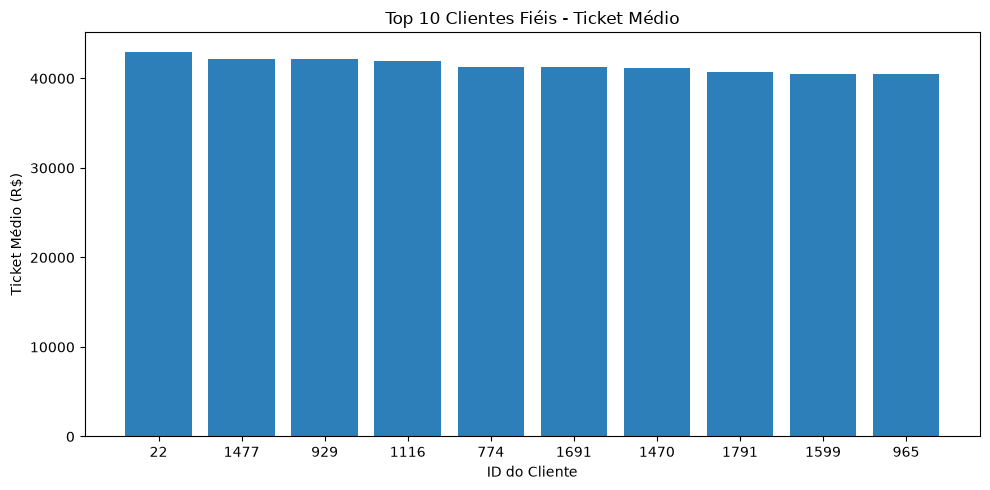

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(df_clientes["customer_id"].astype(str), df_clientes["ticket_medio"], color="#2c7fb8")
plt.title("Top 10 Clientes Fiéis - Ticket Médio")
plt.xlabel("ID do Cliente")
plt.ylabel("Ticket Médio (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Vendas Médias por Dia da Semana (Lojas Físicas) 

Média calculada considerando todos os dias do calendário, inclusive os dias sem venda — corrigindo o erro do cálculo ingênuo que gerou a suspeita inicial do Sr. Almir.

In [9]:
query_calendario = """
WITH limites AS (
    SELECT
        MIN(created_at)::date AS data_min,
        MAX(created_at)::date AS data_max
    FROM orders
    WHERE channel = 'pos'
),
calendario AS (
    SELECT generate_series(data_min, data_max, INTERVAL '1 day')::date AS data
    FROM limites
),
vendas_por_dia AS (
    SELECT
        created_at::date AS data,
        SUM(total) AS venda_diaria
    FROM orders
    WHERE channel = 'pos'
    GROUP BY created_at::date
),
base_final AS (
    SELECT
        c.data,
        COALESCE(v.venda_diaria, 0) AS venda_diaria,
        CASE EXTRACT(DOW FROM c.data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario c
    LEFT JOIN vendas_por_dia v ON c.data = v.data
)
SELECT
    dia_semana,
    ROUND(AVG(venda_diaria), 2) AS media_vendas
FROM base_final
GROUP BY dia_semana
ORDER BY media_vendas ASC;
"""

conexao = conectar()
df_calendario = pd.read_sql_query(query_calendario, conexao)
conexao.close()
df_calendario

/var/folders/07/hkc2jj7d27x_ccfcxgvwt9rr0000gn/T/ipykernel_57657/2574617654.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_calendario = pd.read_sql_query(query_calendario, conexao)


,dia_semana,media_vendas
0,Quinta-feira,157154.32
1,Domingo,157616.13
2,Segunda-feira,158241.15
3,Sábado,164858.27
4,Terça-feira,166118.83
5,Sexta-feira,170193.68
6,Quarta-feira,173605.44


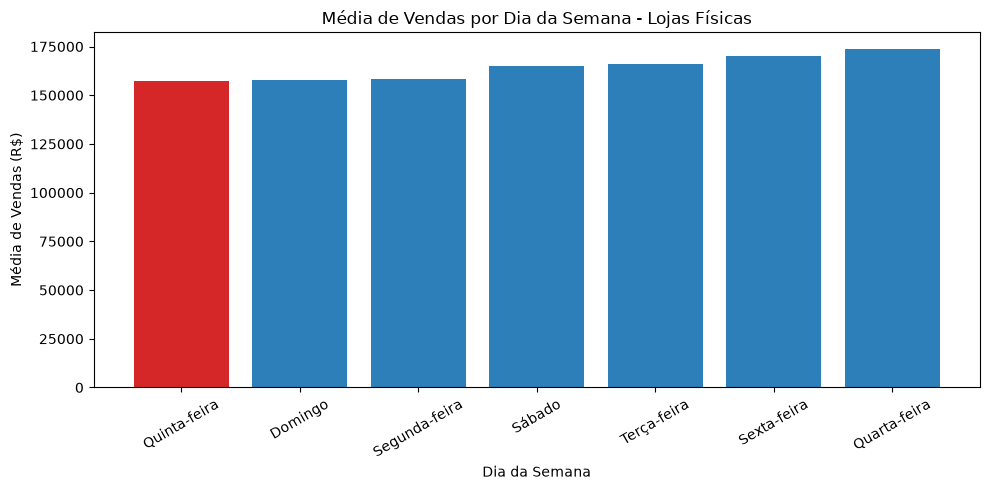

In [7]:
cores = ["#d62728" if i == 0 else "#2c7fb8" for i in range(len(df_calendario))]

plt.figure(figsize=(10, 5))
plt.bar(df_calendario["dia_semana"], df_calendario["media_vendas"], color=cores)
plt.title("Média de Vendas por Dia da Semana - Lojas Físicas")
plt.xlabel("Dia da Semana")
plt.ylabel("Média de Vendas (R$)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Previsão de Demanda - Bússola de Bordo 702 

Baseline de média móvel de 3 meses, comparando previsto vs real para o 1º trimestre de 2026. MAE: 16,44 unidades.

In [8]:
query_bussola = """
SELECT o.created_at::date AS data_venda, oi.quantity
FROM orders o
JOIN order_items oi ON oi.order_id = o.id
JOIN product_variants pv ON pv.id = oi.product_variant_id
WHERE pv.product_id = 74
"""

conexao = conectar()
df_bussola = pd.read_sql_query(query_bussola, conexao)
conexao.close()

df_bussola["data_venda"] = pd.to_datetime(df_bussola["data_venda"])
df_bussola["mes"] = df_bussola["data_venda"].dt.to_period("M")
vendas_mensais = df_bussola.groupby("mes")["quantity"].sum()

calendario_mensal = pd.period_range(start=df_bussola["mes"].min(), end=pd.Period("2026-03", freq="M"), freq="M")
serie_completa = vendas_mensais.reindex(calendario_mensal, fill_value=0)

meses_teste = pd.period_range(start="2026-01", end="2026-03", freq="M")
previsoes = []
for mes in meses_teste:
    historico = serie_completa[serie_completa.index < mes].tail(3)
    previsao = historico.mean() if len(historico) > 0 else 0
    valor_real = serie_completa.get(mes, 0)
    previsoes.append({"mes": str(mes), "real": valor_real, "previsao": round(previsao, 2)})

df_previsoes = pd.DataFrame(previsoes)
df_previsoes

/var/folders/07/hkc2jj7d27x_ccfcxgvwt9rr0000gn/T/ipykernel_57657/3759817425.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bussola = pd.read_sql_query(query_bussola, conexao)


,mes,real,previsao
0,2026-01,69,25.33
1,2026-02,42,39.67
2,2026-03,45,41.67


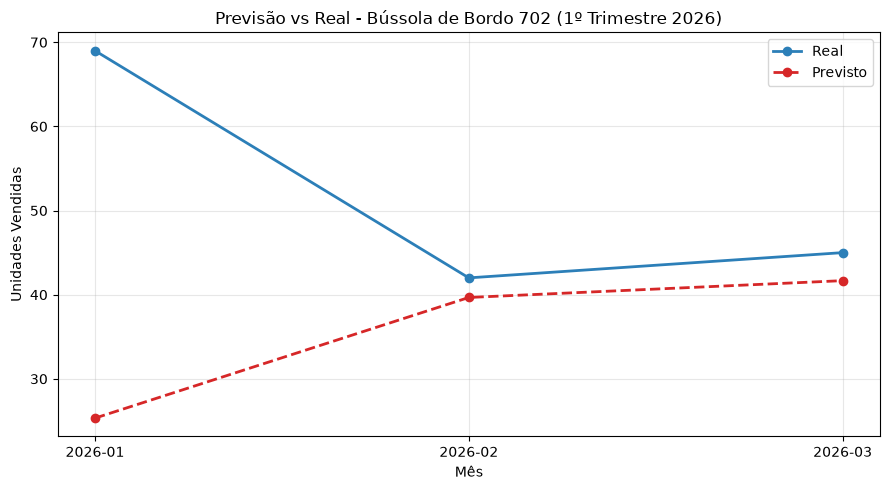

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(df_previsoes["mes"], df_previsoes["real"], marker="o", label="Real", color="#2c7fb8", linewidth=2)
plt.plot(df_previsoes["mes"], df_previsoes["previsao"], marker="o", label="Previsto", color="#d62728", linewidth=2, linestyle="--")
plt.title("Previsão vs Real - Bússola de Bordo 702 (1º Trimestre 2026)")
plt.xlabel("Mês")
plt.ylabel("Unidades Vendidas")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Sistema de Recomendação - Motor de Popa 1949

Top 5 produtos mais similares baseados em similaridade de cosseno, considerando os clientes que compraram cada item.

In [11]:
query_compras = """
SELECT DISTINCT o.customer_id, pv.product_id
FROM orders o
JOIN order_items oi ON oi.order_id = o.id
JOIN product_variants pv ON pv.id = oi.product_variant_id
"""

conexao = conectar()
df_compras = pd.read_sql_query(query_compras, conexao)
conexao.close()

df_compras["comprou"] = 1
matriz = df_compras.pivot_table(index="customer_id", columns="product_id", values="comprou", fill_value=0)

from sklearn.metrics.pairwise import cosine_similarity
similaridade = cosine_similarity(matriz.T)
df_similaridade = pd.DataFrame(similaridade, index=matriz.columns, columns=matriz.columns)

id_produto_ref = 180
similares = df_similaridade[id_produto_ref].sort_values(ascending=False).drop(id_produto_ref)
top5 = similares.head(5)

conexao = conectar()
query_nomes = "SELECT id, name FROM products WHERE id = ANY(%s)"
df_nomes = pd.read_sql_query(query_nomes, conexao, params=(top5.index.tolist(),))
conexao.close()

df_nomes = df_nomes.set_index("id")
ranking = pd.DataFrame({"similaridade": top5, "nome": df_nomes["name"]})
ranking = ranking.sort_values("similaridade", ascending=False)
ranking

/var/folders/07/hkc2jj7d27x_ccfcxgvwt9rr0000gn/T/ipykernel_57657/3535166911.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_compras = pd.read_sql_query(query_compras, conexao)
/var/folders/07/hkc2jj7d27x_ccfcxgvwt9rr0000gn/T/ipykernel_57657/3535166911.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_nomes = pd.read_sql_query(query_nomes, conexao, params=(top5.index.tolist(),))


,similaridade,nome
389,0.256553,Motor de Popa 5331
295,0.256239,Cabo Náutico 2105
75,0.255785,Vela Mestra 1913
337,0.239332,Cabo Náutico 9048
55,0.237744,GPS Plotter 6249


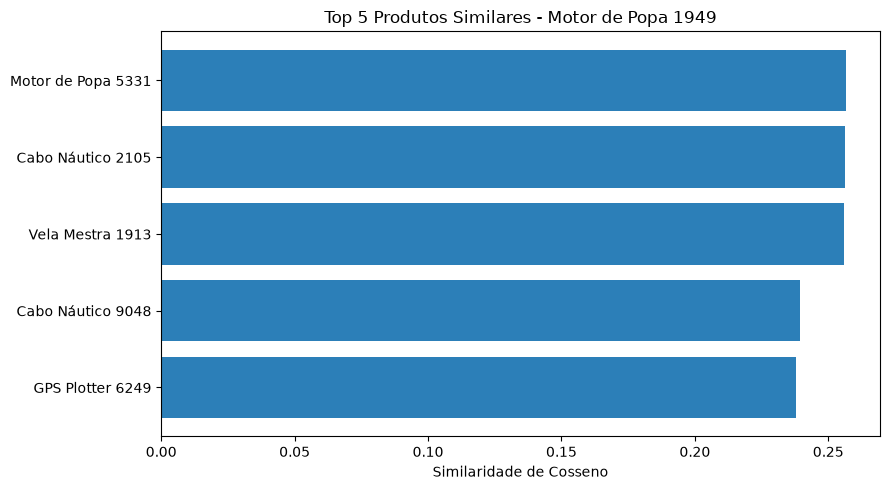

In [12]:
plt.figure(figsize=(9, 5))
plt.barh(ranking["nome"], ranking["similaridade"], color="#2c7fb8")
plt.title("Top 5 Produtos Similares - Motor de Popa 1949")
plt.xlabel("Similaridade de Cosseno")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusão

- **Clientes fiéis**: os 10 clientes de elite têm ticket médio entre R$ 40 mil e R$ 43 mil, todos compraram nas 14 categorias disponíveis — o critério decisivo foi o ticket médio, não a diversidade.

- **Sazonalidade semanal**: Quinta-feira tem a menor média de vendas nas lojas físicas (R$ 157.154,32), mas a variação entre os dias é pequena (~10%), não justificando isoladamente o fechamento de nenhum dia específico.

- **Previsão de demanda**: o baseline de média móvel errou significativamente em janeiro/2026 (previu 25, real foi 69), evidenciando que o método não captura sazonalidade — um ponto de atenção para decisões de compra da Bússola de Bordo 702 em meses de alta temporada.

- **Sistema de recomendação**: o Motor de Popa 5331 é o produto com maior similaridade de compra ao Motor de Popa 1949, sendo o candidato natural para a vitrine "quem comprou isso, também levou".